# Clone-label starts × Potts solvers at dev_tree (#541)

**Rerun at 7d1ba8b (sal b61dfba, #633):** the numbers below are the rerun's. The
deterministic starts and every graph cut reproduce the original. sal b61dfba moves the stochastic paths:
its Potts samplers draw different chains, and its EM (#1136) now fits spectral clustering's states
(0/31 rows fall back to the lattice, against 29/29) and most posterior draws (33/100 fall back, against
92/94). It also adds two solvers, `sal:wolff-heat-bath` and `sal:swendsen-wang-heat-bath` (#1142). The
end-to-end runs ran serially at default threads: at 1 thread, 6 of 16 differ (#638).

**TL;DR.** On dev_tree 60 × 50 r0 (`3381575a`; 6,000 spots, 2 slices), with copy states from
#540's `kmeans++x5+em` and fields built from each start's labels:

- **The solver does not decide the outcome; the start does.** Every graph-cut
  row reaches TRW-S's certified bound on 27 of 29 problems, and is within
  3e-4 nats per spot of it on the other two. The rows are `sal`'s
  `alpha-expansion` and `alpha-beta-swap`, and port's `alpha`,
  `alpha-rust`, `-merge` and `-fuse-merge`. They end at the same labels, in
  0.03–0.06 s (port's pure-Python `alpha`: 2.7 s).
  - ICM, `sal`'s or `cnaster`'s, stops 0.15–0.18 nats per spot above the
    bound.
  - The samplers stop 0.01 above (Swendsen-Wang heat bath 0.004); Wolff and its heat bath 1.2;
    `bifurcation` 3.4.
  - As #492 found, `--sal`'s `alpha-rust-fuse-merge` is as good as any.
- **`grid2`, the pipeline's start, locks its error in.** From its rectangles
  the solve plus floor ends at clone ARI 0.856 with 5 clones. Alternating
  (solve, floor, refit, rebuild) stalls at 0.8605: main's `--sal` dev_tree
  result before #547, 0.8612 with 5 clones.
- **A start that reads `grid2`'s field reaches the planted clones, and so
  does over-partitioning.** Alternated with `--sal`'s solver, each ends at
  clone ARI 0.9989–1.0 with 4 clones:
  - mean field, 0.03 s past the field;
  - 1-hop smoothed argmax;
  - agglomerative clustering along the graph;
  - `grid3` relabelled by the field;
  - a posterior draw;
  - `grid3` itself: 18 rectangles, which the solver and floor merge to 4
    by round 3.

  Each lets the first refit fit clones rather than `grid2`'s 8 rectangles.
  The globally optimal labelling of `grid2`'s own field is not such a start,
  and ends at 0.856.
- **Data-blind starts with too few patches do not:** uniform, Wolff at
  J ≥ 1 (whole slices), spectral clustering (0.57). `umi_grow` and Wolff at
  J = 0.5 reach 0.90–0.92 with 3 clones. `normal-first` (0.86, 5 clones)
  inherits `grid2`'s rectangles outside the normal clone. The field-free
  `BAF agglomerative` reaches 0.92 (3 clones).
- **Joint annealing or sampling of states and labels adds nothing** over
  alternating from the same start (mean field: 0.8597 and 0.9985 against
  0.9989; one chain each, 0.9985 and 0.9993 in the original), and costs
  1.3–1.6× the wall.
- **The coupling:** ×0.1 costs 0.085–0.20 ARI from `grid2`, mean field and
  `normal-first`, and 0.33 from the posterior draw; ×10 changes those three by
  −0.002 to +0.011 and the posterior draw by +0.14 (one draw, seed 0).

**End to end: no start is adopted, and `--sal` keeps its own.** Clone ARI
(clones) / copy ARI. Each run puts the start in place of the first clone
assignment of each stage, on that fit's field, with `--sal` otherwise
(`tests.studies.clone_labels e2e`, #553's `--sal`):

| first assignment | dev_tree r0 (`3381575a`) | dev_shared_unique r0 (`097bb52b`) | CalicoST easy (`2d4ce9a9`) | CalicoST hard (`8797710b`) |
| --- | --- | --- | --- | --- |
| `--sal` (none) | 1.0 (4) / 0.9825 | 0.9983 (4) / 0.9941 | 0.9861 (4) / 0.9035 | 0.9829 (4) / 0.9181 |
| mean field | 1.0 (4) / 0.9825 | 0.9971 (4) / 0.9941 | 0.9861 (4) / 0.9035 | 0.9838 (4) / 0.9135 |
| agglomerative | 0.9587 (4) / 0.9767 | 0.997 (4) / 0.9941 | 0.9861 (4) / 0.9035 | 0.9838 (4) / 0.9135 |
| smoothed argmax 1 | 0.9993 (4) / 0.9825 | 0.926 (5) / 0.9597 | 0.2764 (5) / 0.7313 | 0.8793 (4) / 0.9141 |

- **The stall the study finds is already gone end to end.** The pipeline
  starts the BAF + RDR stage from the BAF stage's clones, not from
  `grid2`, and with #547's seeding those give dev_tree 1.0 (4).
- **Mean field** gains 0.001 clone ARI on hard and costs 0.005 copy ARI there; on
  dev_shared_unique it now costs 0.0012 clone ARI at equal copy ARI (the original:
  +0.001 clone, −0.036 copy).
- **Agglomerative** costs dev_tree 0.041.
- **The smoothed argmax** breaks easy (0.28, 5 clones).

The starts stay in `port.sandbox.clone_starts` with these numbers; the
solver stays `alpha-rust-fuse-merge`.

**Conditions.**
- The capture is one `--sal --oracle-start` run of dev_tree r0 (`3381575a`; spot order
  checked against the truth). Its segmentation is that run's, the planted
  clones' BAF stage. Every field and start is built from labels alone, and
  the planted labels only score.
- The field-reading starts read `grid2`'s field: the profiles `grid2`'s
  labels give.
- `sal`'s EM refused the states of 33 of 100 posterior-draw rows (the
  original: 92 of 94, and all 29 of spectral clustering's). Those rows take
  the lattice's states (`states_by`).
- Stochastic starts: seeds 0–9, solved on 0–2. Stochastic solvers: 3 seeds.
  `field_argmax`, `tempering`, `max-product` and `bifurcation` take no
  start by design.
- 4 spawned workers on the 4-core host; seconds are per job, not isolated.
  End-to-end runs: one at a time, default threads (#638: the result depends on the
  thread count; 3 at once also exceeds the host's 15 GB on dev_tree).
- Regenerate with
  `python -m tests.studies.clone_labels capture SAMPLE CAPTURE.npz`, then
  `run CAPTURE.npz OUT.pkl`, then
  `python -m tests.studies.clone_label_notebook OUT.pkl`.


In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

held = json.loads(Path("data/clone_label_study_r0.json").read_text())
rows = pd.DataFrame(held["rows"])
if "error" not in rows:
    rows["error"] = None
oracle = held["oracle"]
print(
    f"{len(rows)} rows; {rows.error.notna().sum()} refused or crashed; "
    f"the planted labels' own field: ARI {oracle['ari']:.4f}, {oracle['clones']} clones"
)

1276 rows; 0 refused or crashed; the planted labels' own field: ARI 1.0000, 4 clones


## The starts

Each start's labelling before any solver: its clone ARI against the planted labels, its clones and its smallest, and what it and its problem cost -- the copy states (`kmeans++x5+em`), profiles and field its labels give. Stochastic starts over seeds 0-9: median, with the range.

In [ ]:
starts = rows[(rows.arm == "starts") & (rows.solver == "start")]
table = starts.groupby("start", sort=False).agg(
    realizations=("seed", "size"),
    ari=("ari", "median"),
    ari_low=("ari", "min"),
    ari_high=("ari", "max"),
    clones=("clones", "median"),
    smallest=("smallest", "median"),
    start_seconds=("start_seconds", "median"),
    build_seconds=("build_seconds", "median"),
)
table.sort_values("ari", ascending=False).round(4)

,realizations,ari,ari_low,ari_high,clones,smallest,start_seconds,build_seconds
start,,,,,,,,
posterior draw,10,0.8235,0.7865,0.8729,8.0,21.0,0.9887,38.7410
mean field,1,0.8118,0.8118,0.8118,6.0,402.0,0.0178,26.1912
normal-first,1,0.6864,0.6864,0.6864,9.0,109.0,0.0011,41.5604
smoothed argmax 2,1,0.6293,0.6293,0.6293,8.0,224.0,0.0022,39.2192
smoothed argmax 1,1,0.6245,0.6245,0.6245,8.0,215.0,0.0020,39.0754
agglomerative,1,0.5815,0.5815,0.5815,4.0,437.0,0.3093,20.4398
field argmax,1,0.5330,0.5330,0.5330,8.0,409.0,0.0006,44.7267
BAF agglomerative,1,0.4830,0.4830,0.4830,4.0,697.0,0.5223,30.2215
grid3 relabelled,1,0.2861,0.2861,0.2861,8.0,330.0,0.0018,38.2828


## Every solver from every start, the field held

On each start's own field, from its labels (realizations 0-2), `sal`'s methods at #492's budget and port's rows, floorless. The gap is the energy above TRW-S's certified bound on that field, per spot; ARI is read raw and after `--sal`'s floor merge. `field_argmax`, `tempering` and `max-product` take no start (`startless`). Median over starts and seeds.

In [ ]:
solved = rows[
    (rows.arm == "starts") & (rows.solver != "start") & rows.error.isna()
].copy()
solved["gap"] = (solved.energy - solved.bound) / 6000
solvers = solved.groupby("solver").agg(
    gap=("gap", "median"),
    gap_high=("gap", "max"),
    ari=("ari", "median"),
    floored_ari=("floored_ari", "median"),
    floored_ari_low=("floored_ari", "min"),
    clones=("floored_clones", "median"),
    seconds=("solve_seconds", "median"),
)
solvers.sort_values(["floored_ari", "gap"], ascending=[False, True]).round(4)

,gap,gap_high,ari,floored_ari,floored_ari_low,clones,seconds
solver,,,,,,,
port:alpha,0.0000,0.0001,0.8481,0.8479,0.0455,3.0,1.7349
port:alpha-rust,0.0000,0.0001,0.8481,0.8479,0.0455,3.0,0.0323
port:alpha-rust-fuse-merge,0.0000,0.0000,0.8481,0.8479,0.0455,3.0,0.0456
port:alpha-rust-icm,0.0000,0.0002,0.8481,0.8479,0.0455,3.0,0.0644
port:alpha-rust-merge,0.0000,0.0001,0.8481,0.8479,0.0455,3.0,0.0445
sal:alpha-beta-swap,0.0000,0.0000,0.8481,0.8479,0.0455,3.0,0.0273
sal:alpha-expansion,0.0000,0.0001,0.8481,0.8479,0.0455,3.0,0.0240
sal:swendsen-wang-heat-bath,0.0041,0.0306,0.8000,0.8000,0.0455,3.0,0.9849
sal:swendsen-wang,0.0091,0.0960,0.7456,0.7456,0.0336,3.0,0.5777


## The best solver from each start

Per start, the solver whose floored ARI is highest (median over realizations 0-2), beside `--sal`'s `alpha-rust-fuse-merge`: what a start is worth once solved.

In [ ]:
per = solved.pivot_table(
    index="start", columns="solver", values="floored_ari", aggfunc="median"
)
best = pd.DataFrame(
    {
        "start ARI": starts.groupby("start").ari.median(),
        "best solver": per.idxmax(axis=1),
        "its floored ARI": per.max(axis=1),
        "--sal's (alpha-rust-fuse-merge)": per["port:alpha-rust-fuse-merge"],
    }
)
best.sort_values("its floored ARI", ascending=False).round(4)

,start ARI,best solver,its floored ARI,--sal's (alpha-rust-fuse-merge)
start,,,,
mean field,0.8118,port:alpha,1.0000,1.0000
posterior draw,0.8235,port:alpha,0.9991,0.9991
smoothed argmax 2,0.6293,port:alpha,0.9987,0.9987
grid3 relabelled,0.2861,port:alpha,0.9977,0.9977
agglomerative,0.5815,port:alpha,0.9888,0.9888
field argmax,0.5330,port:alpha,0.9651,0.9646
smoothed argmax 1,0.6245,port:alpha,0.9592,0.9592
grid3,0.1537,port:alpha-rust-icm,0.9147,0.9144
wolff J=0.5,0.1259,sal:alpha-beta-swap,0.9056,0.9053


## Runtime against gap, and what each start is worth

Left: each solver's median energy gap per spot above TRW-S's bound against its median solve time, over every start and seed, with the range. Right: each start's clone ARI as it stands (open), after one `--sal` solve and floor (bar), and after four alternating rounds (filled); in brackets, the start's and its states' and field's seconds. This figure replaces #492's `potts_solvers_sal.png` and `potts_solvers_port.png`.

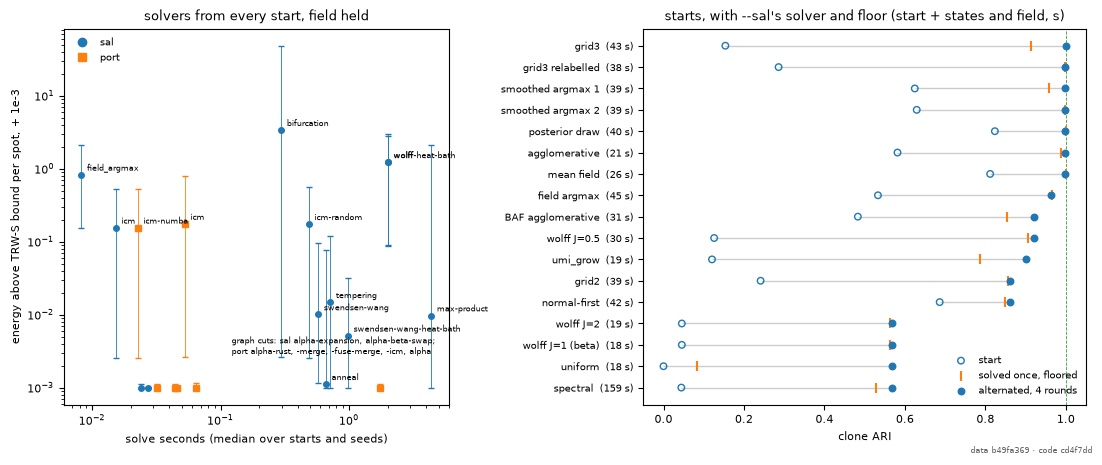

In [ ]:
import hashlib
import subprocess

plt.rcParams.update({"font.size": 8})
figure, (left, right) = plt.subplots(
    1, 2, figsize=(11, 4.6), gridspec_kw={"width_ratios": [1, 1.15]}
)
cuts = {
    "sal:alpha-expansion",
    "sal:alpha-beta-swap",
    "port:alpha",
    "port:alpha-rust",
    "port:alpha-rust-merge",
    "port:alpha-rust-fuse-merge",
    "port:alpha-rust-icm",
}
for solver, group in solved.groupby("solver"):
    x, y = group.solve_seconds.median(), group.gap.median() + 1e-3
    port = solver.startswith("port:")
    left.errorbar(
        x,
        y,
        yerr=[[y - (group.gap.min() + 1e-3)], [group.gap.max() + 1e-3 - y]],
        fmt="s" if port else "o",
        color="C1" if port else "C0",
        ms=4,
        lw=0.6,
        capsize=2,
    )
    if solver not in cuts:
        left.annotate(
            solver.split(":")[1],
            (x, y),
            fontsize=6,
            xytext=(4, 3),
            textcoords="offset points",
        )
left.annotate(
    "graph cuts: sal alpha-expansion, alpha-beta-swap;\nport alpha-rust, -merge, -fuse-merge, -icm, alpha",
    (0.1, 1.1e-3),
    fontsize=6,
    xytext=(8, 22),
    textcoords="offset points",
)
left.plot([], [], "o", color="C0", label="sal")
left.plot([], [], "s", color="C1", label="port")
left.legend(loc="upper left", fontsize=7, frameon=False)
left.set(
    xscale="log",
    yscale="log",
    xlabel="solve seconds (median over starts and seeds)",
    ylabel="energy above TRW-S bound per spot, + 1e-3",
    title="solvers from every start, field held",
)
alternating = rows[(rows.arm == "alternating") & rows.error.isna()]
fuse = (
    solved[solved.solver == "port:alpha-rust-fuse-merge"]
    .groupby("start")
    .floored_ari.median()
)
cost = (
    starts.groupby("start").start_seconds.median()
    + starts.groupby("start").build_seconds.median()
)
start_ari = starts.groupby("start").ari.median()
alt = (
    alternating[
        (alternating.solver == "port:alpha-rust-fuse-merge")
        & (alternating["round"] == 4)
    ]
    .set_index("start")
    .ari
)
order = alt.reindex(start_ari.index).fillna(fuse).sort_values().index
y = np.arange(len(order))
right.hlines(y, start_ari[order], alt.reindex(order), color="0.8", lw=1)
right.scatter(
    start_ari[order],
    y,
    facecolors="none",
    edgecolors="C0",
    s=22,
    label="start",
    zorder=3,
)
right.scatter(
    fuse.reindex(order),
    y,
    marker="|",
    color="C1",
    s=60,
    label="solved once, floored",
    zorder=3,
)
right.scatter(
    alt.reindex(order), y, color="C0", s=22, label="alternated, 4 rounds", zorder=3
)
right.set_yticks(y, [f"{n}  ({cost[n]:.0f} s)" for n in order], fontsize=7)
right.axvline(oracle["ari"], color="C2", lw=0.6, ls="--")
right.legend(loc="lower right", fontsize=7, frameon=False)
right.set(
    xlabel="clone ARI",
    title="starts, with --sal's solver and floor (start + states and field, s)",
)
figure.tight_layout()
data = hashlib.sha256(Path("data/clone_label_study_r0.json").read_bytes()).hexdigest()[
    :8
]
commit = subprocess.run(
    ["git", "rev-parse", "--short=7", "HEAD"],
    capture_output=True,
    text=True,
    check=False,
).stdout.strip()
dirty = subprocess.run(
    [
        "git",
        "status",
        "--porcelain",
        "--untracked-files=no",
        "--",
        "../../python",
        "../../tests",
    ],
    capture_output=True,
    text=True,
    check=False,
).stdout.strip()
figure.text(
    0.995,
    0.005,
    f"data {data} · code {commit or 'unknown'}{'+' if dirty else ''}",
    ha="right",
    va="bottom",
    fontsize=6,
    color="0.4",
)
# NB untracked (`tests.plots_dir`): the figure is this notebook's output above.
Path("../../.cache/plots/studies").mkdir(parents=True, exist_ok=True)
figure.savefig(
    "../../.cache/plots/studies/clone_label_study.png",
    dpi=150,
    metadata={"Software": None},
)

## Alternating: the loop `--sal` runs

Solve, floor, refit the states warm, rebuild the field; four rounds from each start (seed 0) with three solvers. ARI by round, and the wall to the last round.

In [ ]:
alternating = rows[(rows.arm == "alternating") & rows.error.isna()]
rounds = alternating.pivot_table(
    index=["start", "solver"], columns="round", values="ari"
)
rounds["seconds"] = alternating.groupby(["start", "solver"]).seconds.max()
rounds["clones"] = (
    alternating[alternating["round"] == 4].set_index(["start", "solver"]).clones
)
rounds.sort_values(4, ascending=False).round(4)

round                                            0.0     1.0     2.0     3.0  \
start             solver                                                       
grid3             sal:alpha-expansion         0.1537  0.9144  0.9975  1.0000   
                  port:alpha-rust-fuse-merge  0.1537  0.9144  0.9975  1.0000   
agglomerative     port:alpha-rust-fuse-merge  0.5815  0.9888  1.0000  0.9993   
grid3 relabelled  port:alpha-rust-fuse-merge  0.2861  0.9977  1.0000  0.9993   
                  sal:alpha-expansion         0.2861  0.9977  1.0000  0.9993   
agglomerative     sal:alpha-expansion         0.5815  0.9888  1.0000  0.9993   
smoothed argmax 2 sal:alpha-expansion         0.6293  0.9987  0.9989  0.9989   
smoothed argmax 1 port:alpha-rust-fuse-merge  0.6238  0.9996  1.0000  0.9993   
                  sal:alpha-expansion         0.6228  0.9989  0.9989  0.9989   
posterior draw    port:alpha-rust-fuse-merge  0.8193  0.9992  1.0000  0.9993   
mean field        sal:alpha-expansion         0.8115  0.9996  1.0000  0.9993   
smoothed argmax 2 port:alpha-rust-fuse-merge  0.6293  0.9987  0.9989  0.9989   
mean field        port:alpha-rust-fuse-merge  0.8120  0.9986  0.9989  0.9989   
agglomerative     port:icm                    0.5815  0.9874  0.9984  0.9984   
field argmax      port:alpha-rust-fuse-merge  0.5330  0.9646  0.9635  0.9639   
                  sal:alpha-expansion         0.5330  0.9651  0.9635  0.9639   
BAF agglomerative port:alpha-rust-fuse-merge  0.4830  0.8533  0.8587  0.8798   
                  sal:alpha-expansion         0.4830  0.8533  0.8587  0.8798   
wolff J=0.5       sal:alpha-expansion         0.2017  0.9053  0.9205  0.9214   
                  port:alpha-rust-fuse-merge  0.2017  0.9053  0.9205  0.9214   
grid3 relabelled  port:icm                    0.2861  0.8962  0.9011  0.9023   
umi_grow          sal:alpha-expansion         0.1373  0.7320  0.9087  0.9084   
                  port:alpha-rust-fuse-merge  0.1373  0.7320  0.9087  0.9071   
posterior draw    port:icm                    0.8498  0.8886  0.8876  0.8875   
grid2             sal:alpha-expansion         0.2413  0.8562  0.8612  0.8605   
                  port:alpha-rust-fuse-merge  0.2413  0.8562  0.8612  0.8605   
posterior draw    sal:alpha-expansion         0.8193  0.8603  0.8612  0.8605   
normal-first      sal:alpha-expansion         0.6864  0.8479  0.8585  0.8600   
                  port:alpha-rust-fuse-merge  0.6864  0.8479  0.8585  0.8600   
mean field        port:icm                    0.8115  0.8191  0.8199  0.8203   
smoothed argmax 1 port:icm                    0.6245  0.7975  0.8178  0.8180   
field argmax      port:icm                    0.5318  0.7973  0.8143  0.8149   
wolff J=0.5       port:icm                    0.2017  0.7145  0.7808  0.7831   
BAF agglomerative port:icm                    0.4830  0.7144  0.7187  0.7352   
uniform           port:icm                   -0.0000  0.0060  0.3593  0.7676   
smoothed argmax 2 port:icm                    0.6289  0.7348  0.7493  0.7553   
normal-first      port:icm                    0.6864  0.7592  0.7607  0.7602   
umi_grow          port:icm                    0.1373  0.6735  0.7626  0.7677   
grid2             port:icm                    0.2413  0.5732  0.5786  0.5780   
wolff J=1 (beta)  sal:alpha-expansion         0.0455  0.5638  0.5679  0.5680   
wolff J=2         port:alpha-rust-fuse-merge  0.0455  0.5638  0.5679  0.5680   
                  sal:alpha-expansion         0.0455  0.5638  0.5679  0.5680   
wolff J=1 (beta)  port:alpha-rust-fuse-merge  0.0455  0.5638  0.5679  0.5680   
uniform           sal:alpha-expansion        -0.0000  0.0455  0.5638  0.5678   
                  port:alpha-rust-fuse-merge -0.0000  0.0455  0.5638  0.5678   
spectral          sal:alpha-expansion         0.0443  0.5289  0.5673  0.5679   
                  port:alpha-rust-fuse-merge  0.0443  0.5289  0.5673  0.5679   
                  port:icm                    0.0443  0.1854  0.5670  0.5672   


## Joint annealing and sampling of states and labels

From four starts: heat-bath sweeps at T = 8, 4, 2, 1, 0.5 (annealing) or five times at T = 1 keeping the draw of highest data log-likelihood (sampling), the states refitted between, then `alpha-rust-fuse-merge` and the floor. Against alternating with `alpha-rust-fuse-merge` from the same start.

In [ ]:
joint = rows[rows.arm.isin(["joint-anneal", "joint-sample"]) & rows.error.isna()]
final = joint[joint.step == "solved"].set_index(["start", "arm"])[
    ["ari", "clones", "seconds"]
]
fused = alternating[
    (alternating.solver == "port:alpha-rust-fuse-merge") & (alternating["round"] == 4)
]
fused = fused.assign(arm="alternating").set_index(["start", "arm"])[
    ["ari", "clones", "seconds"]
]
pd.concat(
    [
        final,
        fused.loc[
            fused.index.get_level_values(0).isin(final.index.get_level_values(0))
        ],
    ]
).sort_index().round(4)

ari  clones   seconds
start          arm                                   
grid2          alternating   0.8605       5   69.1171
               joint-anneal  0.8014       6   99.6809
               joint-sample  0.9992       4   98.7137
mean field     alternating   0.9989       4   49.6503
               joint-anneal  0.8597       5   86.0172
               joint-sample  0.9985       4   65.5233
normal-first   alternating   0.8601       5   70.5621
               joint-anneal  0.9985       4   97.1292
               joint-sample  0.8479       6   88.0221
posterior draw alternating   0.9989       4   74.3842
               joint-anneal  0.9993       4  106.4132
               joint-sample  0.8601       5   83.8226

## The coupling

The leading starts solved at the run's coupling x 0.1, 1 and 10 (#247, #420), floored.

In [ ]:
beta = rows[(rows.arm == "beta") & rows.error.isna()]
beta.pivot_table(index=["start", "solver"], columns="factor", values="ari").round(4)

factor                                       0.1     1.0     10.0
start          solver                                            
grid2          port:alpha-rust-fuse-merge  0.6608  0.8562  0.8558
               sal:alpha-expansion         0.6668  0.8562  0.8558
mean field     port:alpha-rust-fuse-merge  0.8006  0.9996  0.9974
               sal:alpha-expansion         0.7999  0.9996  0.9974
normal-first   port:alpha-rust-fuse-merge  0.7627  0.8479  0.8587
               sal:alpha-expansion         0.7633  0.8479  0.8587
posterior draw port:alpha-rust-fuse-merge  0.5285  0.8603  0.9965
               sal:alpha-expansion         0.5250  0.8603  0.9965

## Refused and crashed

Every row with an error, by arm and solver.

In [ ]:
errors = rows[rows.error.notna()]
errors.groupby(["arm", "solver"]).error.agg(["size", "first"]) if len(
    errors
) else "none"

'none'